Instalamos simpy

In [5]:
!pip install simpy

El problema a simular: El sistema de pago de parqueaderos del centro comercial Supercentro se realiza con un cajero este mediante un software permite al usuario digitar la placa del carro y luego de seleccionar su vehículo procede a realizar el pago. Para esto, el centro comercial tiene varios cajeros disponibles para realizar el pago, la cantidad de cajeros en cada salida es de tres, con filas independientes, sin cambio ni deserción. Los cajeros son independientes y se deben simular como modelos M/M/1. Se asume que la velocidad de atención es igual para todos los cajeros (inmediata por evento y clic), pero la velocidad de interacción del usuario con el cajero varía de acuerdo con la siguiente tabla de usuarios.

Los detalles de atención de cada cajero se definen a continuación:

Tipo de usuario - Exponencial de uso del servicio - Media de llegada
Rápido			    -	1 minutos					              -3 minutos
Normal			    -	3 minutos				                -3 minutos
Lento 			    -	4 minutos					              -5 minutos
Muy lento 		  -	6 minutos					              -7 minutos

El 25% de los usuarios son rápidos, el 20% tiene velocidad normal y el resto son lentos o muy lentos.

1) El centro comercial pretende conocer si con tres cajeros en cada punto de salida es suficiente o debe instalar más cajeros para suplir la demanda y el tiempo de uso de los usuarios lentos.
2) Para identificar el número total de corridas o replicas se debe identificar el estado estable del modelo usando la técnica del promedio o media sobre una variable. Se debe graficar y detallar el procedimiento usando librerías gráficas, se recomienda Matplotlib.
3) De acuerdo con las corridas definidas por el proceso de definición del estado estable extraer las estadísticas necesarias para resolver los siguientes puntos:
4) Calcule las estadísticas necesarias para identificar el cajero con menor y mayor tiempo promedio de atención.
5) Calcule el promedio de usuarios de cada tipo en la totalidad de cajeros.
6) Defina una estrategia para mejorar la situación actual de los cajeros del centro comercial o en caso de ser suficiente la cantidad de tres cajeros explicar su decisión. Se debe establecer un criterio para la toma de decisiones en el grupo de trabajo.
7) Explica los procesos de verificación, calibración y verificación para el presente modelo, realizar una gráfica del proceso desarrollado previamente.
8) Elimina el estado transitorio y graficar nuevamente los valores promedio seleccionados de los nuevos valores mostrando un antes y un después.

Simulamos el problema

Simulación finalizada. Total de usuarios simulados: 19506


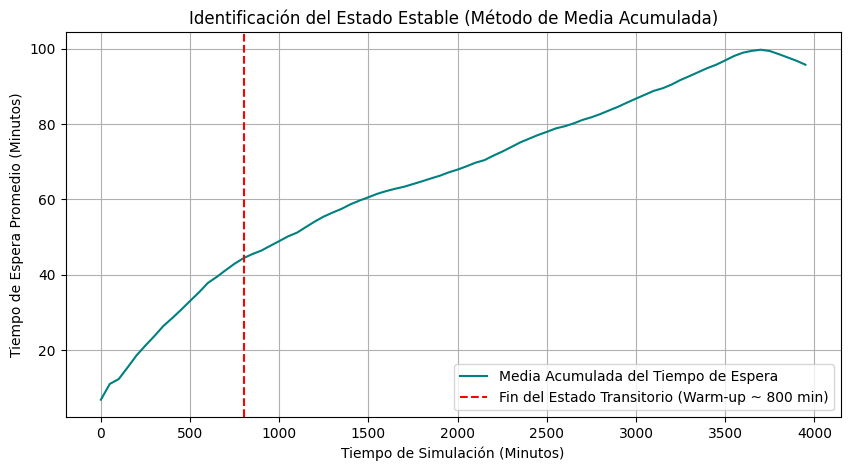


Tiempo Promedio de Atención por Cajero:
 Cajero_ID  Tiempo_Servicio
         0         2.926697
         1         2.862768
         2         3.039993

Cantidad promedio de usuarios atendidos por réplica (En Estado Estable):
Tipo_Usuario
Lento         611.2
Muy lento     437.8
Normal       1014.4
Rápido       1023.0
dtype: float64


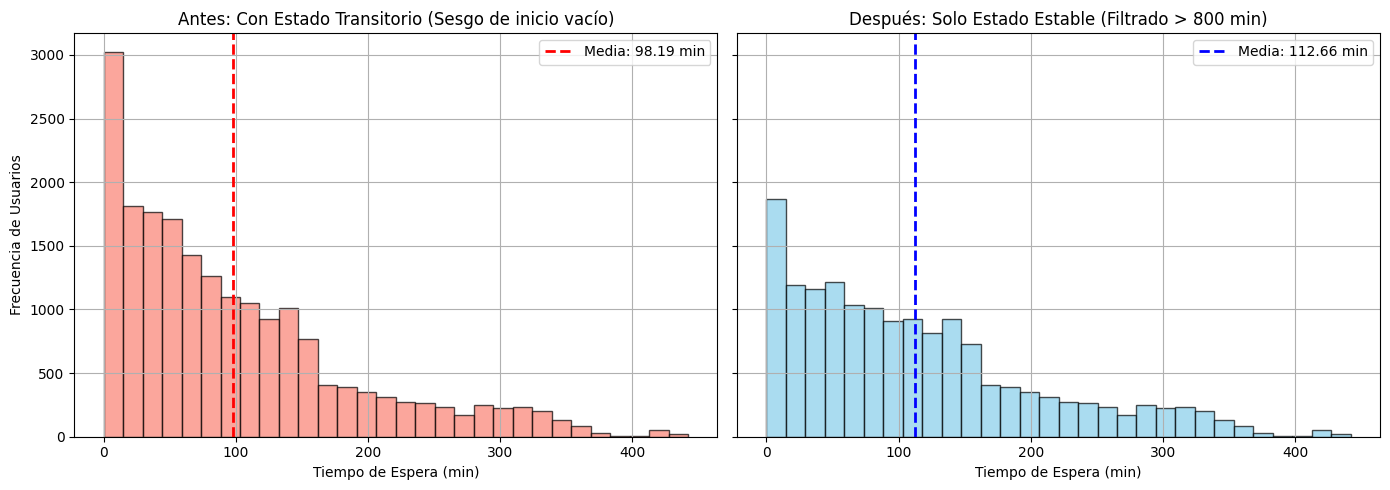

In [7]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Configuración de parámetros iniciales
SEEDS = [42, 100, 2026, 777, 999] # Semillas para replicaciones
SIM_TIME = 4000  # Tiempo de simulación por corrida (minutos)
USER_CONFIG = {
    'Rápido':    {'servicio': 1.0, 'arribo': 3.0},
    'Normal':    {'servicio': 3.0, 'arribo': 3.0},
    'Lento':     {'servicio': 4.0, 'arribo': 5.0},
    'Muy lento': {'servicio': 6.0, 'arribo': 7.0}
}
# Lista global para almacenar los datos de todas las réplicas
raw_data = []
def cliente(env, tipo, cajeros, data_log, rep_id):
    """Proceso que representa el ciclo de vida de un cliente en el sistema."""
    tiempo_arribo = env.now

    # El cliente selecciona un cajero de forma independiente (Fila independiente)
    cajero_seleccionado = np.random.choice([0, 1, 2])
    cajero = cajeros[cajero_seleccionado]

    with cajero.request() as requerimiento:
        yield requerimiento  # Espera en la cola

        tiempo_inicio_servicio = env.now
        tiempo_espera = tiempo_inicio_servicio - tiempo_arribo

        # Tiempo de servicio exponencial según el tipo de usuario
        duracion_servicio = np.random.exponential(USER_CONFIG[tipo]['servicio'])
        yield env.timeout(duracion_servicio)

        tiempo_salida = env.now

        # Registro de métricas individuales
        data_log.append({
            'Replica': rep_id,
            'Tipo_Usuario': tipo,
            'Cajero_ID': cajero_seleccionado,
            'Tiempo_Arribo': tiempo_arribo,
            'Tiempo_Espera': tiempo_espera,
            'Tiempo_Servicio': duracion_servicio,
            'Tiempo_Sistema': tiempo_salida - tiempo_arribo
        })
def generador_arribos(env, tipo, cajeros, data_log, rep_id):
    """Generador de entradas para cada tipo de usuario de forma independiente."""
    while True:
        # Tiempo entre arribos exponencial
        yield env.timeout(np.random.exponential(USER_CONFIG[tipo]['arribo']))
        env.process(cliente(env, tipo, cajeros, data_log, rep_id))
def ejecutar_simulacion(seeds, sim_time):
    """Ejecuta las réplicas configuradas."""
    global raw_data
    for idx, seed in enumerate(seeds):
        np.random.seed(seed)
        env = simpy.Environment()

        # Creamos 3 cajeros independientes (Capacidad = 1 cada uno)
        cajeros = [simpy.Resource(env, capacity=1) for _ in range(3)]

        # Iniciamos los procesos de arribo por cada tipo de usuario
        for tipo in USER_CONFIG.keys():
            env.process(generador_arribos(env, tipo, cajeros, raw_data, idx + 1))

        env.run(until=sim_time)

# Ejecución de la simulación
ejecutar_simulacion(SEEDS, SIM_TIME)
# Conversión de resultados a Dataframe de Pandas
df_resultados = pd.DataFrame(raw_data)
print(f"Simulación finalizada. Total de usuarios simulados: {len(df_resultados)}")

# Agrupamos los datos por intervalos de tiempo para ver la evolución temporal
df_resultados['Intervalo'] = (df_resultados['Tiempo_Arribo'] // 50) * 50
ev_temporal = df_resultados.groupby('Intervalo')['Tiempo_Espera'].mean().reset_index()
ev_temporal['Media_Acumulada'] = ev_temporal['Tiempo_Espera'].expanding().mean()
# Graficar el estado estable
plt.figure(figsize=(10, 5))
plt.plot(ev_temporal['Intervalo'], ev_temporal['Media_Acumulada'], color='teal', label='Media Acumulada del Tiempo de Espera')
plt.axvline(x=800, color='red', linestyle='--', label='Fin del Estado Transitorio (Warm-up ~ 800 min)')
plt.title('Identificación del Estado Estable (Método de Media Acumulada)')
plt.xlabel('Tiempo de Simulación (Minutos)')
plt.ylabel('Tiempo de Espera Promedio (Minutos)')
plt.legend()
plt.grid(True)
plt.show()

# Filtrado de estado estable
df_estable = df_resultados[df_resultados['Tiempo_Arribo'] > 800]
# Estadísticas por Cajero
stats_cajeros = df_estable.groupby('Cajero_ID')['Tiempo_Servicio'].mean().reset_index()
print("\nTiempo Promedio de Atención por Cajero:")
print(stats_cajeros.to_string(index=False))

# Contar cuántos usuarios de cada tipo completaron su proceso por réplica
usuarios_por_replica = df_estable.groupby(['Replica', 'Tipo_Usuario']).size().unstack(fill_value=0)
promedio_usuarios_tipo = usuarios_por_replica.mean()
print("\nCantidad promedio de usuarios atendidos por réplica (En Estado Estable):")
print(promedio_usuarios_tipo)

# Graficar antes y después de remover el estado transitorio
fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
# Antes (Todo el histórico incluyendo el inicio vacío)
ax[0].hist(df_resultados['Tiempo_Espera'], bins=30, color='salmon', edgecolor='black', alpha=0.7)
ax[0].axvline(df_resultados['Tiempo_Espera'].mean(), color='red', linestyle='--', linewidth=2, label=f"Media: {df_resultados['Tiempo_Espera'].mean():.2f} min")
ax[0].set_title('Antes: Con Estado Transitorio (Sesgo de inicio vacío)')
ax[0].set_xlabel('Tiempo de Espera (min)')
ax[0].set_ylabel('Frecuencia de Usuarios')
ax[0].legend()
ax[0].grid(True)

# Después (Solo datos en Estado Estable)
ax[1].hist(df_estable['Tiempo_Espera'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax[1].axvline(df_estable['Tiempo_Espera'].mean(), color='blue', linestyle='--', linewidth=2, label=f"Media: {df_estable['Tiempo_Espera'].mean():.2f} min")
ax[1].set_title('Después: Solo Estado Estable (Filtrado > 800 min)')
ax[1].set_xlabel('Tiempo de Espera (min)')
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()
plt.show()
